In [1]:
import pandas as pd
import numpy as np
from DATA.stock_invest_function import *
from datetime import datetime, timedelta

matplotlib.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

In [79]:
save_path = r"C:\Users\MetaM\PycharmProjects\stock_forecast\DATA"

tic_name = 'CARR'
hs_code = '841590'
item_name = 'PSR'
st_date = '2010-01-01'
end_date = '2025-07-31'
# 오늘 날짜 구하기 (YYYY-MM-DD)
today_date = pd.to_datetime(datetime.today().date())

apikey = 'hT0gAk87j9xZx4PlBApvBqfVL5IahvgV'

db_info = {
    'host' : get_db_host(),
    # 'host' : 'hystox74.synology.me',
    'port' : 3307,
    'user' : 'stox7412',
    'password' : 'Apt106503!~',
    'database' : 'investar'
}

In [80]:
## 미국 기업 재무정보
fundq_df = fetch_table_data(db_info, 'US_fundq')

## 미국 수출 데이터
trade_df = fetch_table_data(db_info, 'us_trade_monthly_data_with_forecast')
#
tickers = [tic_name]
wide_df = get_FMP_data(tickers, apikey)
long_df = reshape_FMP_data(wide_df)
#
accounting_name = 'revenue'
FMP_df = long_df[(long_df['ticker'] == tic_name) & (long_df['accounting_item'] == accounting_name)][['date', 'value']].copy()
FMP_df.rename(columns={'value': tic_name}, inplace=True)

✅ 'US_fundq' 테이블에서 1334117건의 데이터를 가져왔습니다.
✅ 'us_trade_monthly_data_with_forecast' 테이블에서 73818건의 데이터를 가져왔습니다.


Fetching income statements: 100%|██████████| 1/1 [00:00<00:00,  1.33it/s]


In [81]:
endog_df = fundq_df[fundq_df['ticker'] == tic_name][['date', 'saleq']]
endog_df.rename(columns={'saleq' : tic_name}, inplace=True)
endog_month_df = fundq_df[fundq_df['ticker'] == tic_name][['date', 'saleq']]
endog_month_df.rename(columns={'saleq' : tic_name}, inplace=True)

# 날짜 처리 및 분기당 마지막 날짜만 추출
endog_df['date'] = pd.to_datetime(endog_df['date'])
endog_df['quarter'] = endog_df['date'].dt.to_period('Q')
endog_df = endog_df.sort_values('date').groupby('quarter').last().reset_index(drop=True)
endog_df = endog_df[(endog_df['date'] >= st_date) & (endog_df['date'] <= end_date)]

temp_df = trade_df[trade_df['hs_code_6d'] == hs_code][['date','expDlr']]

# 중복 제거
target_export_df = temp_df.drop_duplicates(subset=['date'])

# date를 datetime으로 변환
target_export_df['date'] = pd.to_datetime(target_export_df['date'])

# 분기 추출 및 그룹화
target_export_df['quarter'] = target_export_df['date'].dt.to_period('Q')
quarterly_sum_df = target_export_df.groupby('quarter')['expDlr'].sum().reset_index()

# datetime 변환 후 추가 계산
quarterly_sum_df['quarter'] = quarterly_sum_df['quarter'].dt.to_timestamp()
quarterly_sum_df['export_qoq_change'] = quarterly_sum_df['expDlr'].pct_change(periods=1)
quarterly_sum_df['export_yoy_change'] = quarterly_sum_df['expDlr'].pct_change(periods=4)
quarterly_sum_df['date_month'] = quarterly_sum_df['quarter'] + pd.offsets.QuarterEnd(0)
quarterly_sum_df['date'] = pd.to_datetime(quarterly_sum_df['date_month'])

# date를 인덱스로 설정
quarterly_sum_df.set_index('date', inplace=True)
# ✅ (선택적으로 quarter 컬럼 제거)
quarterly_sum_df.drop(columns='quarter', inplace=True)

quarterly_sum_df = quarterly_sum_df.reset_index()

## nan value  제거
quarterly_sum_df = quarterly_sum_df.iloc[8:]
# 💡 로그변환 제거 → 원시 endog_var 사용
# 💡 외생 변수 exog_var는 표준화(Z-score) 적용
scaler = StandardScaler()
quarterly_sum_df['exog_scaled'] = scaler.fit_transform(quarterly_sum_df[['export_yoy_change']])

merged = merge_endog_exog_data(
    endog_df = endog_df,
    exog_df = quarterly_sum_df,
    endog_col=tic_name,
    exog_col='export_yoy_change',
    start_date= st_date,
    end_date= end_date
)
merged = merged.drop_duplicates(subset=['date', 'endog_var'], keep='first').reset_index()

In [82]:
target_export_df

,date,expDlr,quarter
38691,2013-01-31,92085400.0,2013Q1
38692,2013-02-28,98677700.0,2013Q1
38693,2013-03-31,109172000.0,2013Q1
38694,2013-04-30,121389000.0,2013Q2
38695,2013-05-31,146236000.0,2013Q2
...,...,...,...
38850,2026-04-30,121827000.0,2026Q2
38851,2026-05-31,123132000.0,2026Q2
38852,2026-06-30,130088000.0,2026Q2
38853,2026-07-31,113029000.0,2026Q3


✅ 로그 변환 적용
📎 외생변수 'exog_var' 포함
✅ 로그 변환 적용
🔍 Grid Search 진행 중...
✅ 최적 모형: order=(0, 1, 1), seasonal_order=(0, 0, 0, 4), AIC=-27.79


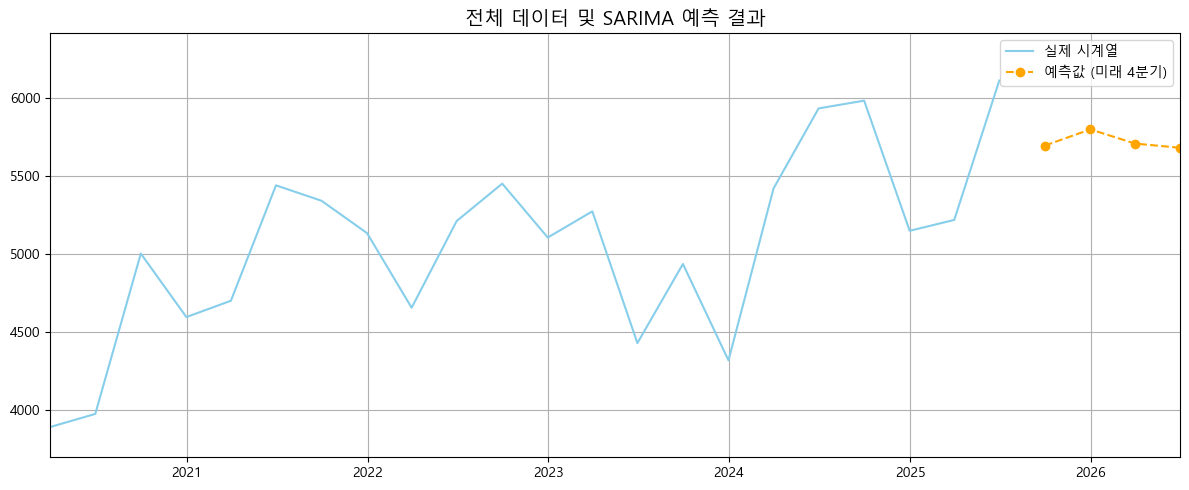


📈 미래 4분기 예측 결과:
2025-09-30    5695.352332
2025-12-31    5799.522359
2026-03-31    5708.324608
2026-06-30    5681.287385
Freq: QE-DEC, Name: predicted_mean, dtype: float64

📊 Ljung-Box Test (잔차 자기상관):
     lb_stat  lb_pvalue
4   0.518383   0.971687
8   2.524716   0.960568
12  2.849666   0.996516


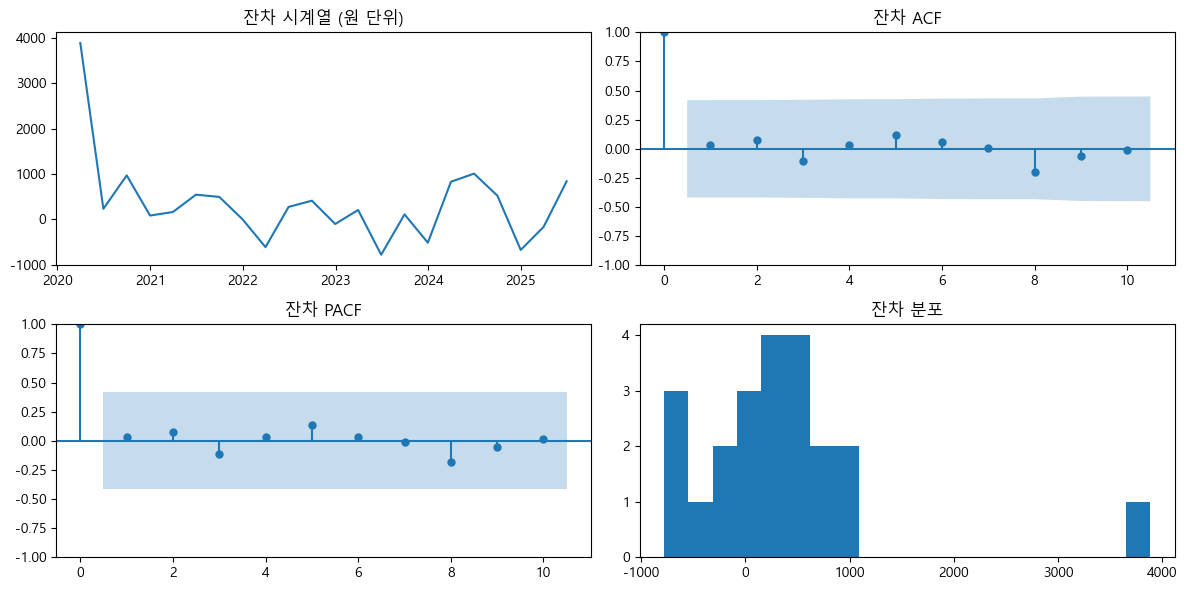

In [83]:
revenue_forecasts_with_exog = forecast_future_4q_with_sarima(merged, value_col='endog_var', exog_col='exog_var', fixed_variable=0)

✅ 로그 변환 적용
✅ 로그 변환 적용
🔍 Grid Search 진행 중...
✅ 최적 모형: order=(0, 1, 1), seasonal_order=(0, 0, 0, 4), AIC=-29.14


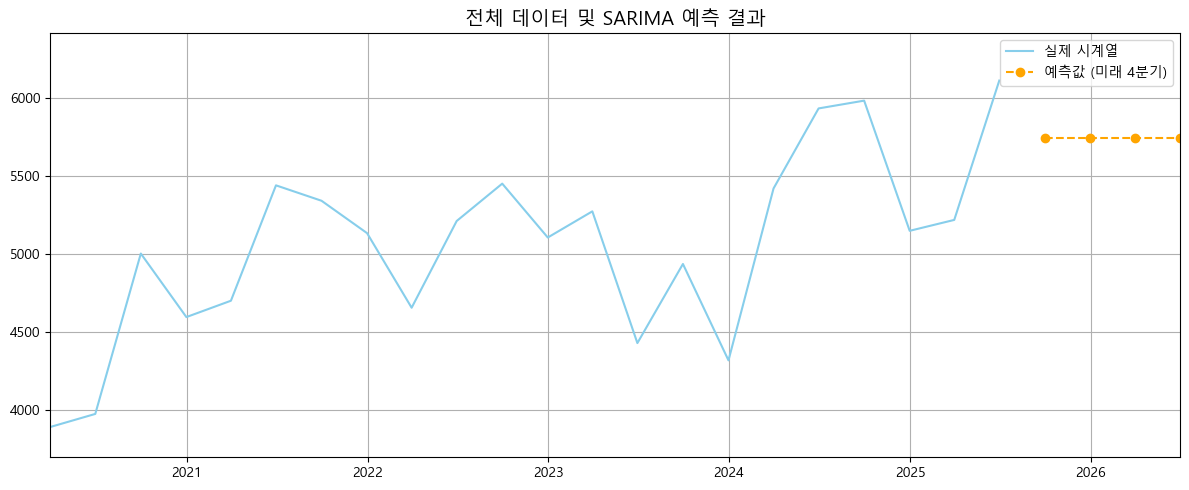


📈 미래 4분기 예측 결과:
2025-09-30    5744.714049
2025-12-31    5744.714049
2026-03-31    5744.714049
2026-06-30    5744.714049
Freq: QE-DEC, Name: predicted_mean, dtype: float64

📊 Ljung-Box Test (잔차 자기상관):
     lb_stat  lb_pvalue
4   0.613304   0.961574
8   2.565640   0.958600
12  2.958345   0.995831


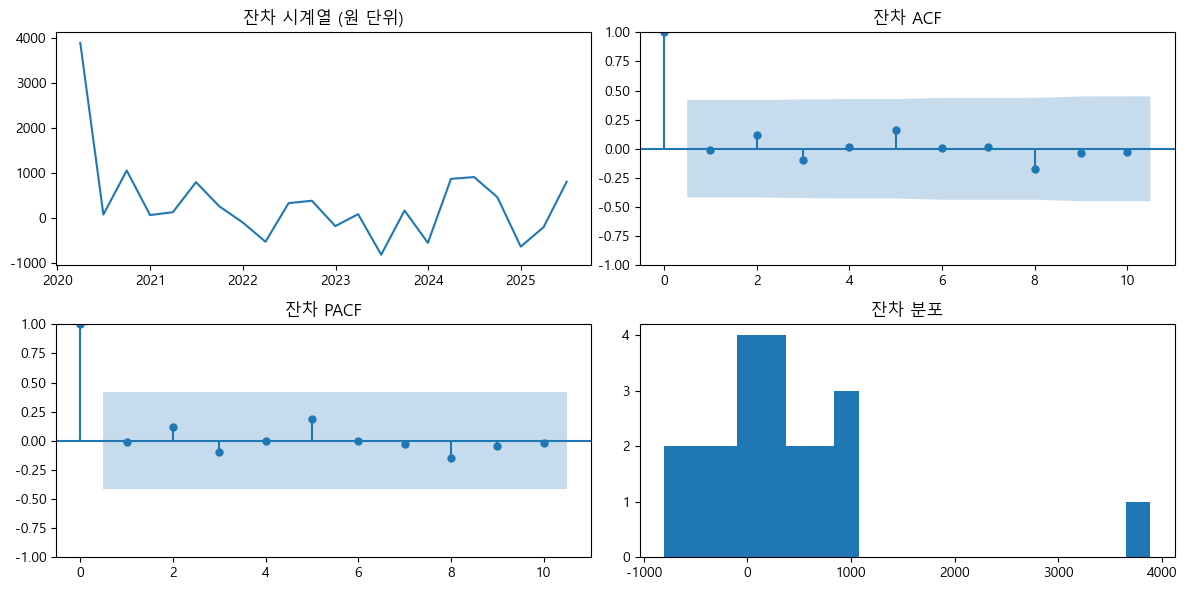

In [84]:
 # 외생변수 포함, 로그 사용, 고정 파라미터로 실행
revenue_forecasts_without_exog = forecast_future_4q_with_sarima(merged, value_col='endog_var', exog_col= None, fixed_variable=0)

In [85]:
# 🔁 결과 저장용 리스트
ratios_timeseries = []

for ticker in tqdm(tickers):
    try:
        url = f"https://financialmodelingprep.com/api/v3/ratios/{ticker}?period=quarter&limit=1000&apikey={apikey}"
        response = requests.get(url)
        data = response.json()

        if isinstance(data, list):
            for entry in data:
                ratios_timeseries.append({
                    'ticker': ticker,
                    'date': entry.get('date'),
                    'PER': entry.get('priceEarningsRatio'),
                    'PBR': entry.get('priceToBookRatio'),
                    'PSR': entry.get('priceToSalesRatio'),
                    'ROE': entry.get('returnOnEquity'),
                    'ROA': entry.get('returnOnAssets'),
                    'DividendPayout': entry.get('payoutRatio')
                })
        else:
            print(f"[⚠️ 없음] {ticker}: 데이터 구조가 예상과 다름")

    except Exception as e:
        print(f"[❌ 오류] {ticker}: {e}")

# 📊 DataFrame으로 변환 및 정렬
df_ratios = pd.DataFrame(ratios_timeseries)
df_ratios.sort_values(by=['ticker', 'date'], inplace=True)

endog_ratio_df = df_ratios[(df_ratios['ticker'] == tic_name)][['date', 'PSR']].copy()

# ✅ Step 1: 날짜 형식 변환
endog_ratio_df['date'] = pd.to_datetime(endog_ratio_df['date'])

# ✅ Step 2: 월 기준으로 분기 판단
def get_standard_quarter(month):
    if month in [1, 2, 3]:
        return 'Q1'
    elif month in [4, 5, 6]:
        return 'Q2'
    elif month in [7, 8, 9]:
        return 'Q3'
    elif month in [10, 11, 12]:
        return 'Q4'
    else:
        return None

# ✅ Step 3: 분기에 따른 일반 분기 종료일 매핑
def get_quarter_end_date(row):
    year = row['date'].year
    quarter = row['quarter']
    if quarter == 'Q1':
        return pd.Timestamp(year=year, month=3, day=31)
    elif quarter == 'Q2':
        return pd.Timestamp(year=year, month=6, day=30)
    elif quarter == 'Q3':
        return pd.Timestamp(year=year, month=9, day=30)
    elif quarter == 'Q4':
        return pd.Timestamp(year=year, month=12, day=31)
    else:
        return pd.NaT

# ✅ Step 4: 파생 변수 추가
endog_ratio_df['quarter'] = endog_ratio_df['date'].dt.month.apply(get_standard_quarter)
endog_ratio_df['aligned_date'] = endog_ratio_df.apply(get_quarter_end_date, axis=1)

# 기존 'date' 칼럼 제거
endog_ratio_df.drop(columns=['date'], inplace=True)
# 'aligned_date' 칼럼을 'date'로 이름 변경
endog_ratio_df.rename(columns={'aligned_date': 'date'}, inplace=True)

merged_ratio_exog = pd.merge(endog_ratio_df, quarterly_sum_df, on = 'date', how = 'left')
merged_ratio_exog = merged_ratio_exog[(merged_ratio_exog['date'] >= '2015-01-01') & (merged_ratio_exog['date'] <= '2026-06')][['date', item_name, 'exog_scaled']].copy()
merged_ratio_exog.rename(columns={item_name : 'endog_var', 'exog_scaled' : 'exog_var'}, inplace=True)

100%|██████████| 1/1 [00:00<00:00,  1.09it/s]


In [86]:
merged_ratio_exog

,date,endog_var,exog_var
0,2019-03-31,2.404441,0.117712
1,2019-06-30,2.094800,0.226889
2,2019-09-30,2.155620,0.092998
3,2019-12-31,2.309353,-0.193008
4,2020-03-31,3.843094,-0.182679
5,2020-06-30,4.845661,-2.901794
6,2020-09-30,5.289855,-0.083739
7,2020-12-31,7.113759,-0.153476
8,2021-03-31,7.810565,-0.377674
9,2021-06-30,7.760813,3.807339


📎 외생변수 'exog_var' 포함
🔍 Grid Search 진행 중...
✅ 최적 모형: order=(1, 1, 1), seasonal_order=(1, 0, 1, 4), AIC=12.00


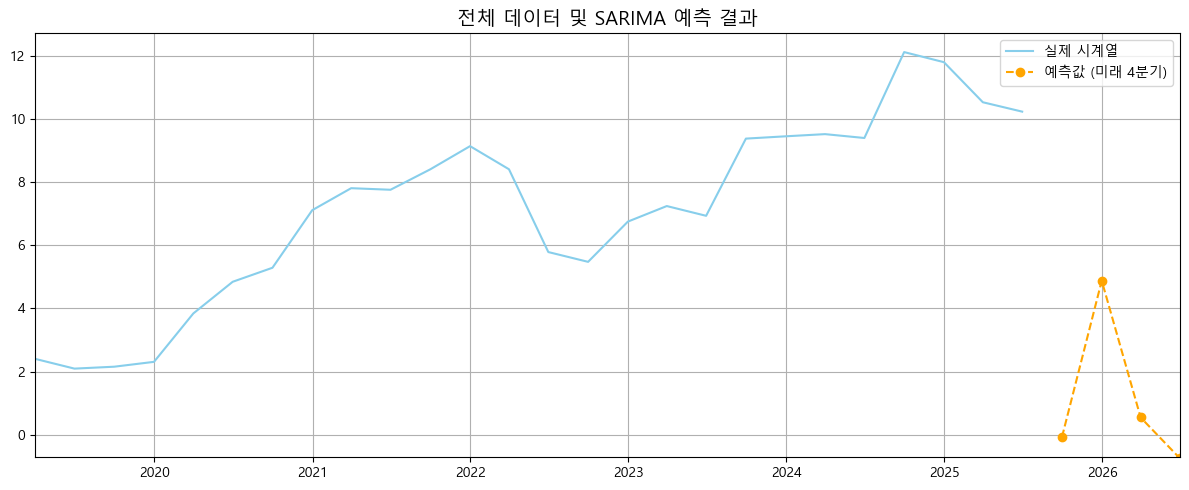


📈 미래 4분기 예측 결과:
2025-09-30   -0.075379
2025-12-31    4.879028
2026-03-31    0.546510
2026-06-30   -0.751252
Freq: QE-DEC, Name: predicted_mean, dtype: float64

📊 Ljung-Box Test (잔차 자기상관):
     lb_stat  lb_pvalue
4   3.388003   0.495111
8   6.657089   0.574041
12  8.443127   0.749614


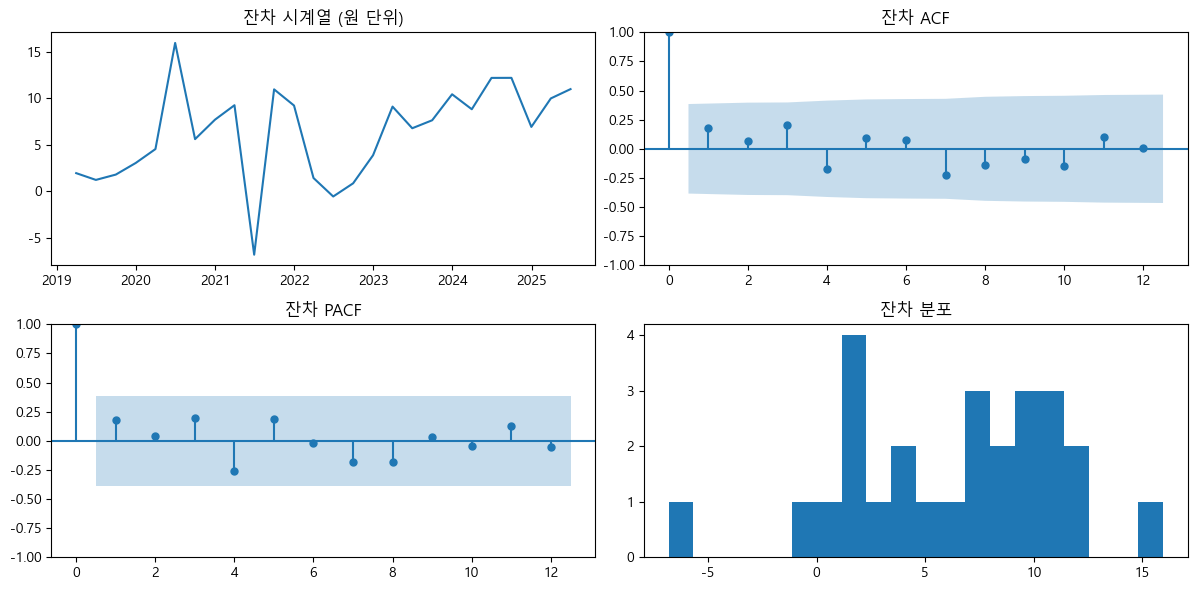

In [87]:
ratio_forecast_result_with_exog = forecast_future_4q_with_sarima(merged_ratio_exog, value_col='endog_var', exog_col='exog_var', use_log= False, fixed_variable=0)

📎 외생변수 'exog_var' 포함
🔍 Grid Search 진행 중...
✅ 최적 모형: order=(1, 1, 1), seasonal_order=(1, 0, 1, 4), AIC=12.00


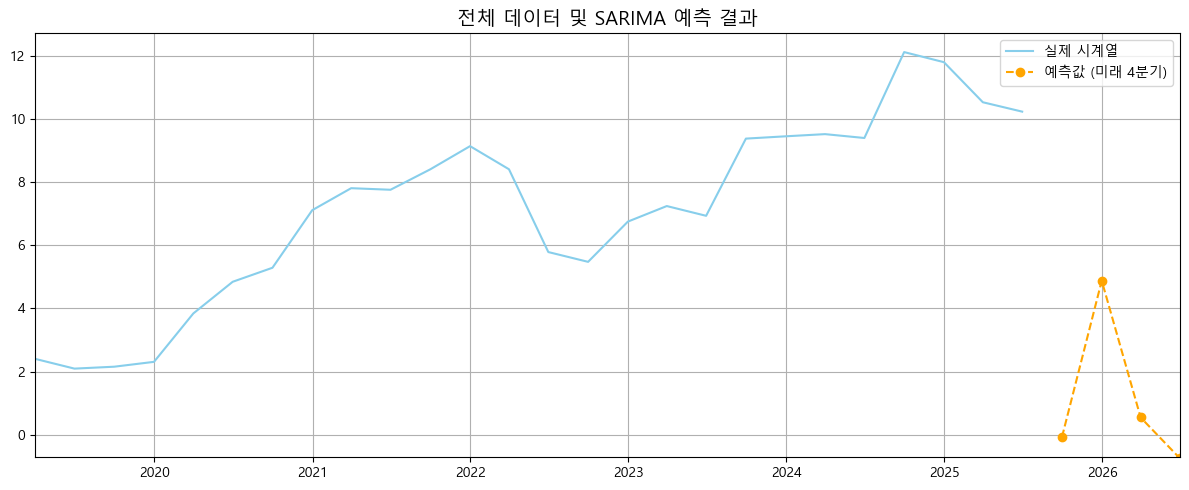


📈 미래 4분기 예측 결과:
2025-09-30   -0.075379
2025-12-31    4.879028
2026-03-31    0.546510
2026-06-30   -0.751252
Freq: QE-DEC, Name: predicted_mean, dtype: float64

📊 Ljung-Box Test (잔차 자기상관):
     lb_stat  lb_pvalue
4   3.388003   0.495111
8   6.657089   0.574041
12  8.443127   0.749614


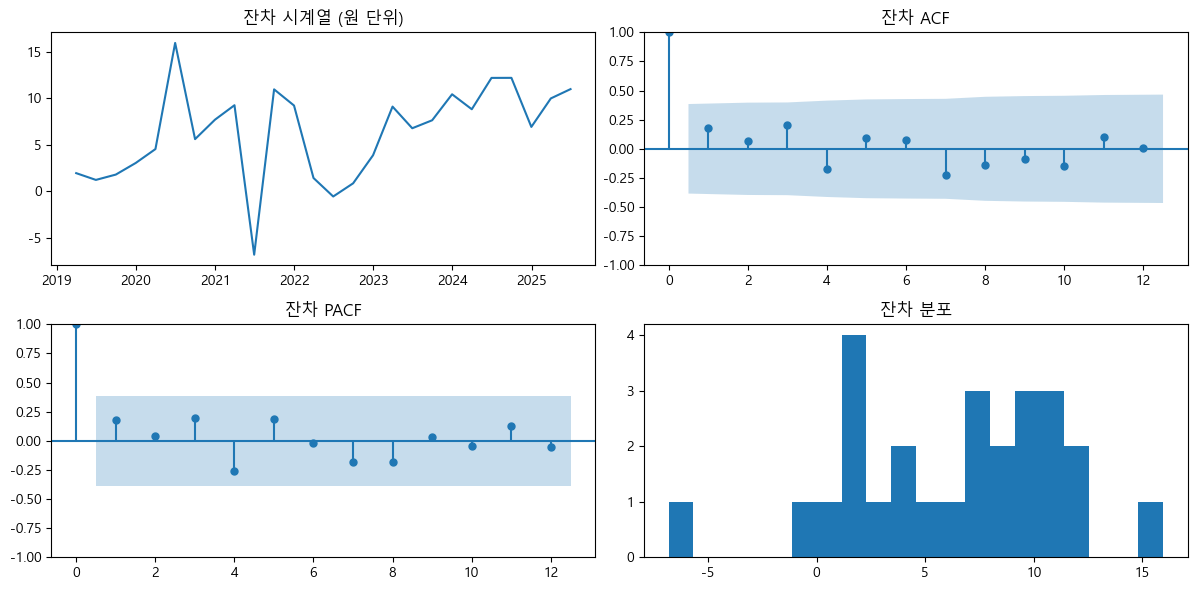

In [88]:
ratio_forecast_result_without_exog  = forecast_future_4q_with_sarima(merged_ratio_exog, value_col='endog_var', exog_col='exog_var', use_log= False, fixed_variable=0)

In [89]:
symbol = tic_name

# 📌 날짜 설정: 2019-01-01 ~ 어제 날짜
from_date = '2019-01-01'
to_date = (datetime.today() - timedelta(days=1)).strftime('%Y-%m-%d')

df_market = get_market_cap(symbol, apikey, from_date, to_date)

# 잘못된 to_timestamp 인자를 수정하고 다시 실행

# 1. 분기별 매출 데이터 재정렬 및 rolling TTM 계산
df_revenue = FMP_df.sort_values("date").reset_index(drop=True)
df_revenue["TTM_Revenue"] = df_revenue[tic_name].rolling(window=4).sum()

# 전제: df_market (일일 시가총액), df_revenue (분기별 TTM 매출)
df_revenue = df_revenue.sort_values('date')
df_market = df_market.sort_values('date')

lstm_forecast = forecast_ratio_with_lstm(df_market, df_revenue)

df_daily_psr = pd.merge_asof(
    df_market,
    df_revenue[['date', 'TTM_Revenue']],
    left_on='date',
    right_on='date',
    direction='backward'
)

# PSR 계산
df_daily_psr['PSR'] = df_daily_psr['marketCap'] / df_daily_psr['TTM_Revenue']
df_daily_psr = df_daily_psr.dropna(subset=['PSR'])


In [90]:
# 1. df_daily_psr 를 월별 마지막 데이터로 축소
df_monthly_psr = df_daily_psr.copy()
df_monthly_psr['date'] = pd.to_datetime(df_monthly_psr['date'])
df_monthly_psr = df_monthly_psr.set_index('date').resample('M').last().reset_index()

# 2. target_export_df 의 date 도 datetime 으로 변환
target_export_df['date'] = pd.to_datetime(target_export_df['date'])
target_export_df['final_expDlr_yoy'] = target_export_df['expDlr'].pct_change(periods=12)

# 3. 두 데이터프레임을 date 기준으로 left join
merged_monthly_df = pd.merge(
    df_monthly_psr[['date', 'PSR']],
    target_export_df[['date', 'final_expDlr_yoy']],
    on='date',
    how='left'
)

# 4. 컬럼명 변경
merged_monthly_df = merged_monthly_df.rename(columns={
    'date': 'date',
    'PSR': 'endog_var',
    'final_expDlr_yoy': 'exog_var'
})

# 5. 결과 확인
print(merged_monthly_df.head())

        date  endog_var  exog_var
0 2020-06-30   1.120375 -0.125380
1 2020-07-31   1.373493 -0.068050
2 2020-08-31   1.505095 -0.050741
3 2020-09-30   1.523922  0.097505
4 2020-10-31   1.666135  0.001387


In [91]:
# forecast_future_4q_with_sarima(merged_value_exog , date_col='date', value_col='endog_var', exog_col=None,  use_log=False, fixed_variable=0)
ratio_forecast_monthly_result_without_exog = forecast_future_with_sarima(merged_monthly_df, freq='M', forecast_steps=12, date_col='date', value_col='endog_var', exog_col=None,  use_log=False, fixed_variable=0)
ratio_forecast_monthly_result_with_exog = forecast_future_with_sarima(merged_monthly_df, freq='M', forecast_steps=12, date_col='date', value_col='endog_var', exog_col='exog_var',  use_log=False, fixed_variable=0)

🔍 주기 설정: seasonal_period = 12
🔍 Grid Search 진행 중...
✅ 최적 모형: order=(0, 1, 0), seasonal_order=(0, 0, 0, 12), AIC=-39.72
🔍 주기 설정: seasonal_period = 12
📎 외생변수 'exog_var' 포함
🔍 Grid Search 진행 중...
✅ 최적 모형: order=(0, 1, 0), seasonal_order=(0, 0, 0, 12), AIC=-37.78


In [92]:
# Prophet 포맷에 맞게 데이터 정리 (컬럼: ds, y)
df_prophet = df_daily_psr.copy()
df_prophet = df_prophet.rename(columns={'date': 'ds', 'PSR': 'y'})
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])

# Prophet 모델 선언 및 학습
model = Prophet(daily_seasonality=True, yearly_seasonality=True)
model.fit(df_prophet)

# 향후 예측 날짜 생성 (예: 90일)
future = model.make_future_dataframe(periods=90)
prophet_forecast = model.predict(future)

# # 시각화
# fig1 = model.plot(prophet_forecast)
# plt.title("PSR Forecast using Prophet")
# plt.xlabel("Date")
# plt.ylabel("PSR")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

22:57:23 - cmdstanpy - INFO - Chain [1] start processing
22:57:23 - cmdstanpy - INFO - Chain [1] done processing


In [93]:
revenue_forecasts_with_exog =  revenue_forecasts_with_exog.rename('revenue_with_exog')
revenue_forecasts_without_exog = revenue_forecasts_without_exog.rename('revenue_without_exog')

# revenue_with_exog 값 합산
total_revenue_with_exog = revenue_forecasts_with_exog.sum()
total_revenue_without_exog = revenue_forecasts_without_exog.sum()

# 방법 1: 장기 valuation
value_forecast_with_exog = ratio_forecast_result_with_exog.rename('PSR_quarter_with_exog')
value_forecast_without_exog = ratio_forecast_result_without_exog.rename('PSR_quarter_without_exog')

# 방법 2: 중기 valuation
value_forecast_monthly_without_exog = ratio_forecast_monthly_result_without_exog.rename(
    columns={'forecast': 'PSR_monthly_without_exog'}
)

value_forecast_monthly_with_exog = ratio_forecast_monthly_result_with_exog.rename(
    columns={'forecast': 'PSR_monthly_with_exog'}
)

# 방법 3: 단기 valuation
lstm_forecast = lstm_forecast.rename({'forecasted_PSR': 'PSR_daily_lstm'}, axis=1)
prophet_forecast_resize = prophet_forecast[['ds', 'trend']].rename(columns={'ds': 'date', 'trend': 'PSR_daily_prophet'})

# concat 시 모든 forecast 포함
longterm_value_forecasts = pd.concat(
    [value_forecast_with_exog, value_forecast_without_exog, revenue_forecasts_with_exog, revenue_forecasts_without_exog],
    axis=1
)

longterm_value_forecasts['revenue_with_exog_sum'] = longterm_value_forecasts['revenue_with_exog'].sum()
longterm_value_forecasts['revenue_without_exog_sum'] = longterm_value_forecasts['revenue_without_exog'].sum()
longterm_value_forecasts['value_with_exog'] = longterm_value_forecasts['PSR_quarter_with_exog'] * longterm_value_forecasts['revenue_with_exog_sum']
longterm_value_forecasts['value_without_exog'] = longterm_value_forecasts['PSR_quarter_without_exog'] * longterm_value_forecasts['revenue_without_exog_sum']

# concat 시 모든 forecast 포함
midterm_value_forecasts = pd.concat(
    [value_forecast_monthly_with_exog, value_forecast_monthly_without_exog],
    axis=1
)

midterm_value_forecasts['revenue_with_exog'] = total_revenue_with_exog
midterm_value_forecasts['revenue_without_exog'] = total_revenue_without_exog
midterm_value_forecasts['value_with_exog'] = midterm_value_forecasts['PSR_monthly_with_exog'] * midterm_value_forecasts['revenue_with_exog']
midterm_value_forecasts['value_without_exog'] = midterm_value_forecasts['PSR_monthly_without_exog'] * midterm_value_forecasts['revenue_without_exog']


lstm_forecast_indexed = lstm_forecast.set_index('date')
prophet_forecast_resize_indexed = prophet_forecast_resize.set_index('date')

# concat 시 모든 forecast 포함
shortterm_value_forecasts = pd.concat(
    [lstm_forecast_indexed , prophet_forecast_resize_indexed],
    axis=1, join = 'inner'
)

# shortterm_value_forecasts에 동일 값으로 컬럼 추가
shortterm_value_forecasts['revenue_with_exog'] = total_revenue_with_exog
shortterm_value_forecasts['revenue_without_exog'] = total_revenue_without_exog
# LSTM 기준 가치 계산
shortterm_value_forecasts['lstm_value_with_exog'] = shortterm_value_forecasts['PSR_daily_lstm'] * shortterm_value_forecasts['revenue_with_exog']
shortterm_value_forecasts['lstm_value_without_exog'] = shortterm_value_forecasts['PSR_daily_lstm'] * shortterm_value_forecasts['revenue_without_exog']
# Prophet 기준 가치 계산
shortterm_value_forecasts['prophet_value_with_exog'] = shortterm_value_forecasts['PSR_daily_prophet'] * shortterm_value_forecasts['revenue_with_exog']
shortterm_value_forecasts['prophet_value_without_exog'] = shortterm_value_forecasts['PSR_daily_prophet'] * shortterm_value_forecasts['revenue_without_exog']

longterm_value_forecasts['frequency'] = 'Q'
midterm_value_forecasts['frequency'] = 'M'
shortterm_value_forecasts['frequency'] = 'D'

longterm_value_forecasts['ticker'] = tic_name
midterm_value_forecasts['ticker'] = tic_name
shortterm_value_forecasts['ticker'] = tic_name

longterm_value_forecasts['forecast_date'] = today_date
midterm_value_forecasts['forecast_date'] = today_date
shortterm_value_forecasts['forecast_date'] = today_date

# 공통적으로 melt (long format)
def melt_forecast_df(df):
    return df.melt(
        id_vars=['frequency', 'ticker', 'forecast_date'],
        var_name='indicator',
        value_name='value'
    )

# 각각 melt
longterm_melted = melt_forecast_df(longterm_value_forecasts)
midterm_melted = melt_forecast_df(midterm_value_forecasts)
shortterm_melted = melt_forecast_df(shortterm_value_forecasts)

# 모두 concat
combined_long_format = pd.concat(
    [longterm_melted, midterm_melted, shortterm_melted],
    axis=0,
    ignore_index=True
)

combined_long_format

,frequency,ticker,forecast_date,indicator,value
0,Q,CARR,2025-08-31,PSR_quarter_with_exog,-0.075379
1,Q,CARR,2025-08-31,PSR_quarter_with_exog,4.879028
2,Q,CARR,2025-08-31,PSR_quarter_with_exog,0.546510
3,Q,CARR,2025-08-31,PSR_quarter_with_exog,-0.751252
4,Q,CARR,2025-08-31,PSR_quarter_without_exog,-0.075379
...,...,...,...,...,...
347,D,CARR,2025-08-31,prophet_value_without_exog,56703.047943
348,D,CARR,2025-08-31,prophet_value_without_exog,56685.961809
349,D,CARR,2025-08-31,prophet_value_without_exog,56668.875676
350,D,CARR,2025-08-31,prophet_value_without_exog,56651.789542


In [94]:
combined_long_format

,frequency,ticker,forecast_date,indicator,value
0,Q,CARR,2025-08-31,PSR_quarter_with_exog,-0.075379
1,Q,CARR,2025-08-31,PSR_quarter_with_exog,4.879028
2,Q,CARR,2025-08-31,PSR_quarter_with_exog,0.546510
3,Q,CARR,2025-08-31,PSR_quarter_with_exog,-0.751252
4,Q,CARR,2025-08-31,PSR_quarter_without_exog,-0.075379
...,...,...,...,...,...
347,D,CARR,2025-08-31,prophet_value_without_exog,56703.047943
348,D,CARR,2025-08-31,prophet_value_without_exog,56685.961809
349,D,CARR,2025-08-31,prophet_value_without_exog,56668.875676
350,D,CARR,2025-08-31,prophet_value_without_exog,56651.789542


In [40]:
combined_long_format[(combined_long_format['indicator'] == 'value_without_exog') & (combined_long_format['frequency'] == 'M')]

,frequency,ticker,forecast_date,indicator,value
92,M,LRCX,2025-07-02,value_without_exog,126732.229288
93,M,LRCX,2025-07-02,value_without_exog,116529.348822
94,M,LRCX,2025-07-02,value_without_exog,113788.599325
95,M,LRCX,2025-07-02,value_without_exog,124622.782015
96,M,LRCX,2025-07-02,value_without_exog,122636.832629
97,M,LRCX,2025-07-02,value_without_exog,131739.287922
98,M,LRCX,2025-07-02,value_without_exog,134678.882375
99,M,LRCX,2025-07-02,value_without_exog,131112.338121
100,M,LRCX,2025-07-02,value_without_exog,126383.322996
101,M,LRCX,2025-07-02,value_without_exog,136359.888165


In [36]:
# revenue_forecasts_with_exog =  revenue_forecasts_with_exog.rename('revenue_with_exog')
# revenue_forecasts_without_exog = revenue_forecasts_without_exog.rename('revenue_without_exog')
#
# # 방법 1: 장기 valuation
# value_forecast_with_exog = value_forecast_with_exog.rename('PSR_quarter_with_exog')
# value_forecast_without_exog = value_forecast_without_exog.rename('PSR_quarter_without_exog')
#
# # 방법 2: 단기 valuation
# lstm_forecast = lstm_forecast.rename({'forecasted_PSR': 'PSR_daily_lstm'}, axis=1)
# prophet_forecast_resize = prophet_forecast[['ds', 'trend']].rename(columns={'ds': 'date', 'trend': 'PSR_daily_prophet'})
#
# # concat 시 모든 forecast 포함
# longterm_value_forecasts = pd.concat(
#     [value_forecast_with_exog, value_forecast_without_exog, revenue_forecasts_with_exog, revenue_forecasts_without_exog],
#     axis=1
# )
#
# longterm_value_forecasts['value_with_exog'] = longterm_value_forecasts['PSR_quarter_with_exog'] * longterm_value_forecasts['revenue_with_exog']
# longterm_value_forecasts['value_without_exog'] = longterm_value_forecasts['PSR_quarter_with_exog'] * longterm_value_forecasts['revenue_with_exog']
#
# lstm_forecast_indexed = lstm_forecast.set_index('date')
# prophet_forecast_resize_indexed = prophet_forecast_resize.set_index('date')
#
# # concat 시 모든 forecast 포함
# shortterm_value_forecasts = pd.concat(
#     [lstm_forecast_indexed , prophet_forecast_resize_indexed],
#     axis=1, join = 'inner'
# )
#
# # revenue_with_exog 값 합산
# total_revenue_with_exog = revenue_forecasts_with_exog.sum()
# total_revenue_without_exog = revenue_forecasts_without_exog.sum()
#
# # shortterm_value_forecasts에 동일 값으로 컬럼 추가
# shortterm_value_forecasts['revenue_with_exog'] = total_revenue_with_exog
# shortterm_value_forecasts['revenue_without_exog'] = total_revenue_without_exog
#
# # LSTM 기준 가치 계산
# shortterm_value_forecasts['lstm_value_with_exog'] = shortterm_value_forecasts['PSR_daily_lstm'] * shortterm_value_forecasts['revenue_with_exog']
# shortterm_value_forecasts['lstm_value_without_exog'] = shortterm_value_forecasts['PSR_daily_lstm'] * shortterm_value_forecasts['revenue_without_exog']
#
# # Prophet 기준 가치 계산
# shortterm_value_forecasts['prophet_value_with_exog'] = shortterm_value_forecasts['PSR_daily_prophet'] * shortterm_value_forecasts['revenue_with_exog']
# shortterm_value_forecasts['prophet_value_without_exog'] = shortterm_value_forecasts['PSR_daily_prophet'] * shortterm_value_forecasts['revenue_without_exog']

In [13]:
# # 오늘 날짜를 'YYYY-MM-DD' 문자열로
# today_str = datetime.today().strftime('%Y-%m-%d')
#
#
# # ticker 컬럼 추가
# shortterm_value_forecasts['ticker'] = tic_name
# longterm_value_forecasts['ticker'] = tic_name
#
# # reset_index + index 이름 바꾸기
# shortterm_df_reindex = shortterm_value_forecasts.reset_index().rename(columns={'index': 'date'})
# longterm_df_reindex = longterm_value_forecasts.reset_index().rename(columns={'index': 'date'})
#
# # long format 변환
# shortterm_df = shortterm_df_reindex.melt(
#     id_vars=['date', 'ticker'],
#     var_name='indicator',
#     value_name='value'
# )
# longterm_df = longterm_df_reindex.melt(
#     id_vars=['date', 'ticker'],
#     var_name='indicator',
#     value_name='value'
# )
#
# # forecast_data 컬럼에 추가
# shortterm_df['forecast_date'] = today_str
# longterm_df['forecast_date'] = today_str
#
# engine = create_engine(
#     f"mysql+pymysql://{db_info['user']}:{db_info['password']}@{db_info['host']}:{db_info['port']}/{db_info['database']}"
# )
#
# # 테이블 처음 생성 시
# shortterm_df.to_sql(
#     name='US_short_term_valuaion_result',
#     con=engine,
#     if_exists='replace',  # 처음만 replace
#     index=False
# )
#
# # longterm 데이터도 같은 방식
# longterm_df.to_sql(
#     name='US_long_term_valuaion_result',
#     con=engine,
#     if_exists='replace',  # 처음만 replace
#     index=False
# )

30